In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")



df = pd.read_csv("train.csv")


df = df.drop(columns=["ID", "ethnicity", "contry_of_res", "relation", "age_desc", "result"])


label_encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


important_columns = [
    'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
    'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score',
    'age', 'gender', 'jaundice', 'austim', 'used_app_before'
]
X = df[important_columns]
y = df["Class/ASD"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {test_accuracy * 100:.2f}%")


cv = StratifiedKFold(n_splits=5)
cv_scores = cross_val_score(model, X_resampled, y_resampled, cv=cv, scoring='accuracy')
print(f"Cross-Validated Accuracy: {cv_scores.mean() * 100:.2f}%")




[LightGBM] [Info] Number of positive: 508, number of negative: 514
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 428
[LightGBM] [Info] Number of data points in the train set: 1022, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497065 -> initscore=-0.011742
[LightGBM] [Info] Start training from score -0.011742
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("train.csv")
df = df.drop(columns=["ID", "age_desc", "relation"])  

label_encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


cv = StratifiedKFold(n_splits=5)
cv_scores = cross_val_score(model, X_balanced, y_balanced, cv=cv, scoring="accuracy")
print(f"Cross-Validated Accuracy: {cv_scores.mean() * 100:.2f}%")




Test Accuracy: 89.84%
Cross-Validated Accuracy: 90.85%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("train.csv")


df = df.drop(columns=["ID", "age_desc", "relation"])


label_encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)


model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.9,
    min_child_weight=2,
    gamma=0.2,
    reg_lambda=1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f" Test Accuracy: {test_acc * 100:.2f}%")




✅ Test Accuracy: 91.02%


🔻 Dropping low-importance features: ['used_app_before']
✅ Test Accuracy: 89.84%
✅ Cross-Validated Accuracy: 91.24%


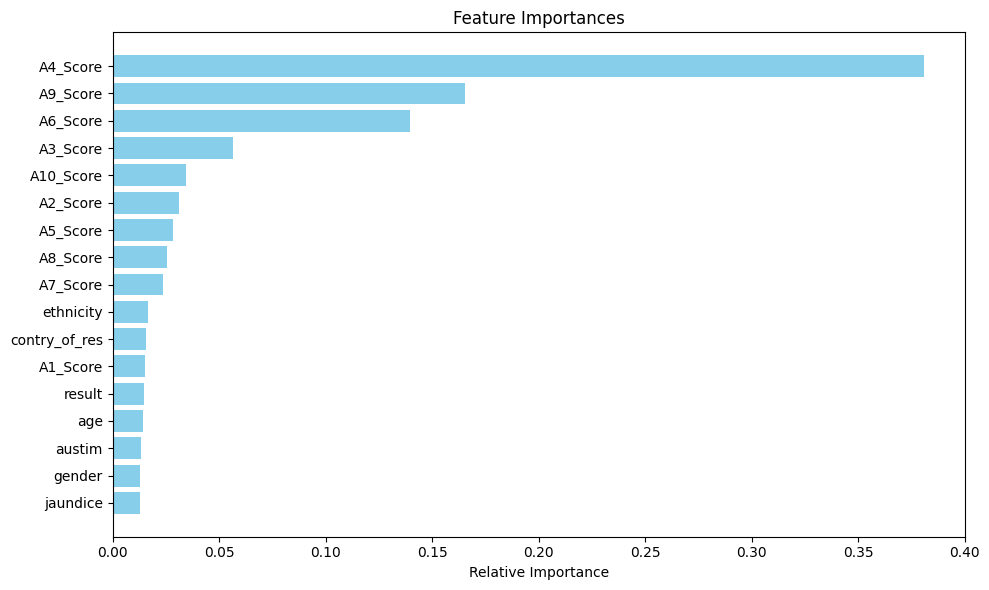

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("train.csv")


df = df.drop(columns=["ID", "age_desc", "relation"])


label_encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"].astype(int)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)


temp_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.9,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
temp_model.fit(X_train, y_train)

importances = temp_model.feature_importances_
feature_names = X.columns
low_features = [feature_names[i] for i in range(len(importances)) if importances[i] < 0.01]



X = X.drop(columns=low_features)

X_scaled = scaler.fit_transform(X)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)


model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.9,
    min_child_weight=2,
    gamma=0.2,
    reg_lambda=1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


cv = StratifiedKFold(n_splits=5)
cv_scores = cross_val_score(model, X_resampled, y_resampled, cv=cv, scoring="accuracy")
print(f" Cross-Validated Accuracy: {cv_scores.mean() * 100:.2f}%")


importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="skyblue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df = pd.read_csv("train.csv")
df = df.drop(columns=["ID", "age_desc", "relation"])


label_encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"].astype(int)


X["total_score"] = X[[col for col in X.columns if "_Score" in col]].sum(axis=1)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)


X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1).to(device)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


class ASDNet(nn.Module):
    def __init__(self, input_dim):
        super(ASDNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


model = ASDNet(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

model.eval()
with torch.no_grad():
    preds = model(X_test_tensor)
    preds_class = (preds > 0.5).float()
    accuracy = (preds_class.eq(y_test_tensor).sum().item()) / y_test_tensor.size(0)
    print(f"\n PyTorch Model Test Accuracy: {accuracy * 100:.2f}%")

# Plot training loss
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()



✅ Using device: cuda
Epoch 10/100, Loss: 0.2576
Epoch 20/100, Loss: 0.1903


KeyboardInterrupt: 

Using device: cuda
Epoch 10/150, Loss: 8.0338, Val Acc: 88.67%
Epoch 20/150, Loss: 5.9641, Val Acc: 90.62%
Epoch 30/150, Loss: 4.5624, Val Acc: 91.02%
Epoch 40/150, Loss: 3.2040, Val Acc: 91.41%
Epoch 50/150, Loss: 3.0521, Val Acc: 91.02%
Epoch 60/150, Loss: 2.4444, Val Acc: 90.62%
Epoch 70/150, Loss: 2.5237, Val Acc: 91.41%
Epoch 80/150, Loss: 1.7655, Val Acc: 91.41%
Epoch 90/150, Loss: 1.8939, Val Acc: 91.80%
Epoch 100/150, Loss: 1.7269, Val Acc: 91.80%
Epoch 110/150, Loss: 1.6904, Val Acc: 91.41%
Epoch 120/150, Loss: 1.4319, Val Acc: 91.80%
Epoch 130/150, Loss: 1.6381, Val Acc: 92.19%
Epoch 140/150, Loss: 1.5728, Val Acc: 91.41%
Epoch 150/150, Loss: 1.3015, Val Acc: 92.19%

🎯 Final Test Accuracy: 92.97%


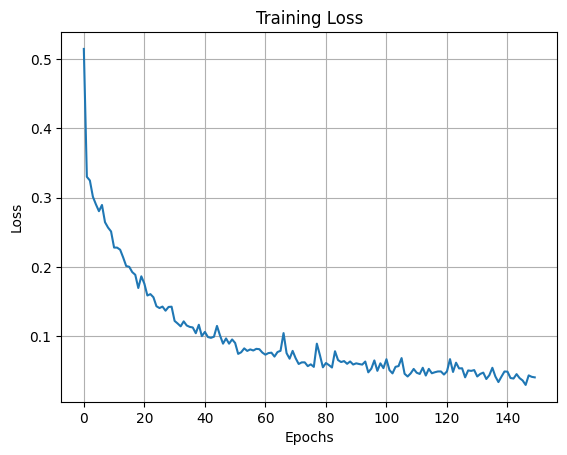

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


df = pd.read_csv("train.csv")
df.drop(columns=["ID", "age_desc", "relation"], inplace=True)

le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le


df["total_score"] = df[[col for col in df.columns if "_Score" in col]].sum(axis=1)
df["score_range"] = df[[col for col in df.columns if "_Score" in col]].max(axis=1) - df[[col for col in df.columns if "_Score" in col]].min(axis=1)
df["average_score"] = df[[col for col in df.columns if "_Score" in col]].mean(axis=1)


X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"].astype(int)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)

train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)


class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007)


best_acc = 0
train_losses = []
epochs = 150

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        val_preds = (val_preds > 0.5).float()
        acc = (val_preds.eq(y_test).sum().item()) / y_test.size(0)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    train_losses.append(total_loss / len(train_loader))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}, Val Acc: {acc*100:.2f}%")

model.load_state_dict(torch.load("best_model.pt"))
model.eval()
with torch.no_grad():
    final_preds = (model(X_test) > 0.5).float()
    final_acc = (final_preds.eq(y_test).sum().item()) / y_test.size(0)
    print(f"\n🎯 Final Test Accuracy: {final_acc * 100:.2f}%")


plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()







Using device: cuda
Cleaned Columns: ['id', 'a1_score', 'a2_score', 'a3_score', 'a4_score', 'a5_score', 'a6_score', 'a7_score', 'a8_score', 'a9_score', 'a10_score', 'age', 'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'class/asd']
Epoch 10/200 | Loss: 18.5619 | Val Acc: 88.67%
Epoch 20/200 | Loss: 13.3647 | Val Acc: 91.80%
Epoch 30/200 | Loss: 11.6103 | Val Acc: 91.02%
Epoch 40/200 | Loss: 10.8415 | Val Acc: 91.41%
Epoch 50/200 | Loss: 11.0099 | Val Acc: 90.23%
Epoch 60/200 | Loss: 9.8465 | Val Acc: 91.41%
Epoch 70/200 | Loss: 7.8846 | Val Acc: 91.02%
Epoch 80/200 | Loss: 9.3983 | Val Acc: 90.62%
Epoch 90/200 | Loss: 7.8197 | Val Acc: 91.80%
Epoch 100/200 | Loss: 7.9445 | Val Acc: 91.02%
Epoch 110/200 | Loss: 7.6661 | Val Acc: 91.02%
Epoch 120/200 | Loss: 7.2637 | Val Acc: 91.41%
Epoch 130/200 | Loss: 7.2275 | Val Acc: 91.41%
Epoch 140/200 | Loss: 7.2489 | Val Acc: 91.80%
Epoch 150/200 | Loss: 7.0154 | Val Acc: 91.80%


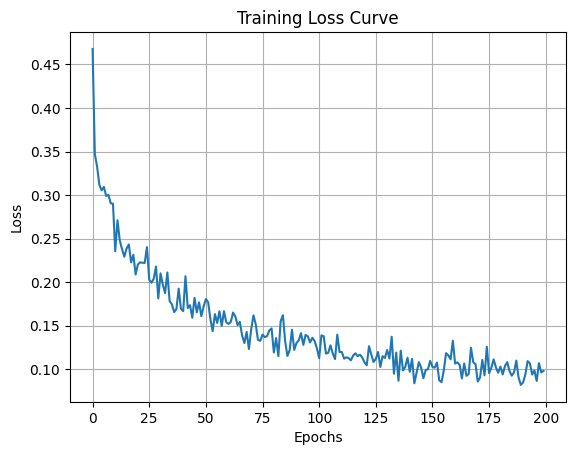

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


df = pd.read_csv("train.csv")


df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
print("Cleaned Columns:", df.columns.tolist())


for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)


le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le


score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)

binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]


target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)


X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)


train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)


best_acc = 0
train_losses = []
epochs = 200

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        val_preds = (val_preds > 0.5).float()
        acc = (val_preds.eq(y_test).sum().item()) / y_test.size(0)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    train_losses.append(total_loss / len(train_loader))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Val Acc: {acc*100:.2f}%")


model.load_state_dict(torch.load("best_model.pt"))


model.eval()
with torch.no_grad():
    final_preds = (model(X_test) > 0.5).float()
    final_acc = (final_preds.eq(y_test).sum().item()) / y_test.size(0)
    print(f"\n🎯 Final Test Accuracy: {final_acc * 100:.2f}%")


plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()





Using device: cuda
Cleaned Columns: ['id', 'a1_score', 'a2_score', 'a3_score', 'a4_score', 'a5_score', 'a6_score', 'a7_score', 'a8_score', 'a9_score', 'a10_score', 'age', 'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'class/asd']
Epoch 10/200 | Loss: 17.4923 | Val Acc: 89.84%
Epoch 20/200 | Loss: 15.9440 | Val Acc: 89.84%
Epoch 30/200 | Loss: 14.2243 | Val Acc: 90.23%
Epoch 40/200 | Loss: 12.5455 | Val Acc: 90.62%
Epoch 50/200 | Loss: 13.5511 | Val Acc: 91.02%
Epoch 60/200 | Loss: 9.8792 | Val Acc: 89.84%
Epoch 70/200 | Loss: 9.0781 | Val Acc: 90.23%
Epoch 80/200 | Loss: 8.3804 | Val Acc: 89.84%
Epoch 90/200 | Loss: 8.2914 | Val Acc: 91.02%
Epoch 100/200 | Loss: 6.5945 | Val Acc: 91.02%
Epoch 110/200 | Loss: 7.5273 | Val Acc: 91.80%
Epoch 120/200 | Loss: 7.9561 | Val Acc: 91.80%
Epoch 130/200 | Loss: 7.2771 | Val Acc: 92.58%
Epoch 140/200 | Loss: 7.9600 | Val Acc: 91.41%
Epoch 150/200 | Loss: 5.8598 | Val Acc: 92.58%


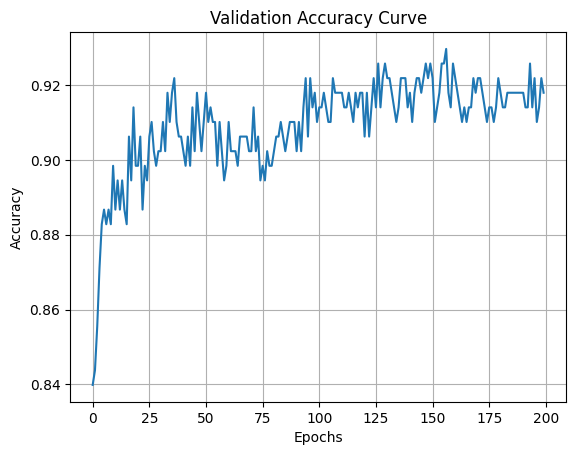

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


df = pd.read_csv("train.csv")


df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
print("Cleaned Columns:", df.columns.tolist())

for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)

binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]


target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)


X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)



train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)


best_acc = 0
val_accuracies = []
epochs = 200

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        val_preds = (val_preds > 0.5).float()
        acc = (val_preds.eq(y_test).sum().item()) / y_test.size(0)
        val_accuracies.append(acc)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Val Acc: {acc*100:.2f}%")

model.load_state_dict(torch.load("best_model.pt"))

model.eval()
with torch.no_grad():
    final_preds = (model(X_test) > 0.5).float()
    final_acc = (final_preds.eq(y_test).sum().item()) / y_test.size(0)
    print(f"\n🎯 Final Test Accuracy: {final_acc * 100:.2f}%")

plt.plot(val_accuracies)
plt.title("Validation Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


Using device: cuda
Epoch 10/200 | Accuracy: 89.84%
Epoch 20/200 | Accuracy: 91.41%
Epoch 30/200 | Accuracy: 91.80%
Epoch 40/200 | Accuracy: 90.23%
Epoch 50/200 | Accuracy: 90.23%
Epoch 60/200 | Accuracy: 91.41%
Epoch 70/200 | Accuracy: 91.41%
Epoch 80/200 | Accuracy: 90.23%
Epoch 90/200 | Accuracy: 91.02%
Epoch 100/200 | Accuracy: 91.80%
Epoch 110/200 | Accuracy: 91.41%
Epoch 120/200 | Accuracy: 91.02%
Epoch 130/200 | Accuracy: 91.80%
Epoch 140/200 | Accuracy: 92.19%
Epoch 150/200 | Accuracy: 91.41%
Epoch 160/200 | Accuracy: 91.80%
Epoch 170/200 | Accuracy: 92.19%
Epoch 180/200 | Accuracy: 91.41%
Epoch 190/200 | Accuracy: 92.19%
Epoch 200/200 | Accuracy: 92.19%

🎯 Final Test Accuracy: 92.97%
📈 Mean Average Precision (mAP): 0.9010


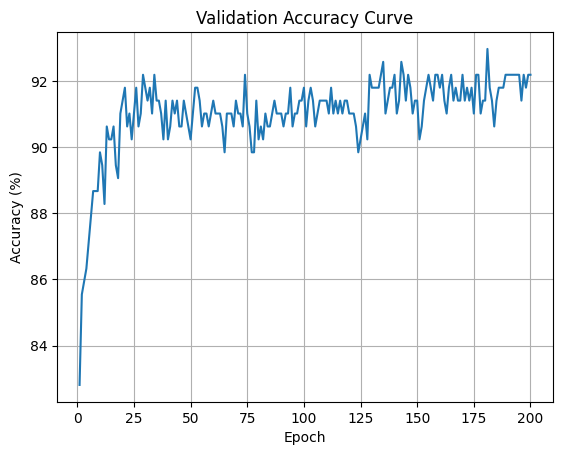

In [ ]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


df = pd.read_csv("train.csv")
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

\
for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)


le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le


score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)
binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]


target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)


X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)


train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 200
best_acc = 0
acc_list = []

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        acc = (val_preds.round() == y_test).float().mean().item()
        acc_list.append(acc)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Accuracy: {acc * 100:.2f}%")


model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    final_preds = model(X_test)
    final_acc = (final_preds.round() == y_test).float().mean().item()
    map_score = average_precision_score(y_test.cpu().numpy(), final_preds.cpu().numpy())
    print(f"\n🎯 Final Test Accuracy: {final_acc * 100:.2f}%")
    print(f"📈 Mean Average Precision (mAP): {map_score:.4f}")


plt.plot(range(1, epochs + 1), [a * 100 for a in acc_list])
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


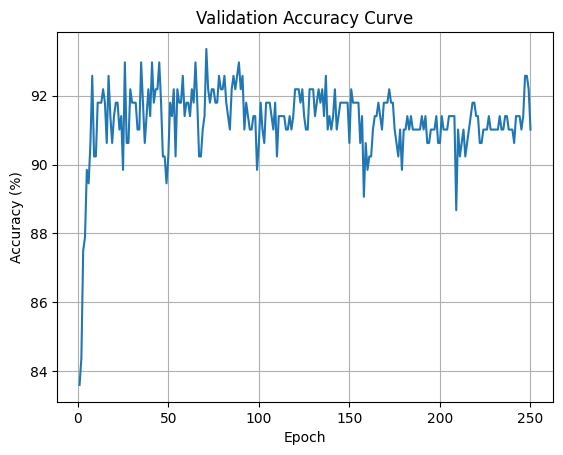

(0.93359375, np.float64(0.9044864460389733))

In [ ]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, average_precision_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df = pd.read_csv("train.csv")
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)
binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]
df["interaction_term"] = df["binary_sum"] * df["total_score"]

target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

poly = PolynomialFeatures(2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets):
        BCE_loss = self.bce(inputs, targets)
        pt = torch.exp(-BCE_loss)
        return (1 - pt) ** self.gamma * BCE_loss

class UpgradedDNN(nn.Module):
    def __init__(self, input_dim):
        super(UpgradedDNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = UpgradedDNN(X_train.shape[1]).to(device)
criterion = FocalLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005)
epochs = 250

best_acc = 0
acc_list = []

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        acc = (val_preds.round() == y_test).float().mean().item()
        acc_list.append(acc)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "train.csv")

model.load_state_dict(torch.load("train.csv"))
model.eval()
with torch.no_grad():
    final_preds = model(X_test)
    final_acc = (final_preds.round() == y_test).float().mean().item()
    map_score = average_precision_score(y_test.cpu().numpy(), final_preds.cpu().numpy())

plt.plot(range(1, epochs+1), [a * 100 for a in acc_list])
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

final_acc, map_score


Using device: cuda
Epoch 10/2000 | Accuracy: 89.84%
Epoch 20/2000 | Accuracy: 91.41%
Epoch 30/2000 | Accuracy: 91.80%
Epoch 40/2000 | Accuracy: 90.23%
Epoch 50/2000 | Accuracy: 90.23%
Epoch 60/2000 | Accuracy: 91.41%
Epoch 70/2000 | Accuracy: 91.41%
Epoch 80/2000 | Accuracy: 90.23%
Epoch 90/2000 | Accuracy: 91.02%
Epoch 100/2000 | Accuracy: 91.80%
Epoch 110/2000 | Accuracy: 91.41%
Epoch 120/2000 | Accuracy: 91.02%
Epoch 130/2000 | Accuracy: 91.80%
Epoch 140/2000 | Accuracy: 92.19%
Epoch 150/2000 | Accuracy: 91.41%
Epoch 160/2000 | Accuracy: 91.80%
Epoch 170/2000 | Accuracy: 92.19%
Epoch 180/2000 | Accuracy: 91.41%
Epoch 190/2000 | Accuracy: 92.19%
Epoch 200/2000 | Accuracy: 92.19%
Epoch 210/2000 | Accuracy: 91.80%
Epoch 220/2000 | Accuracy: 92.19%
Epoch 230/2000 | Accuracy: 91.41%
Epoch 240/2000 | Accuracy: 91.41%
Epoch 250/2000 | Accuracy: 91.41%
Epoch 260/2000 | Accuracy: 91.80%
Epoch 270/2000 | Accuracy: 92.19%
Epoch 280/2000 | Accuracy: 91.80%
Epoch 290/2000 | Accuracy: 92.19%
Epoc

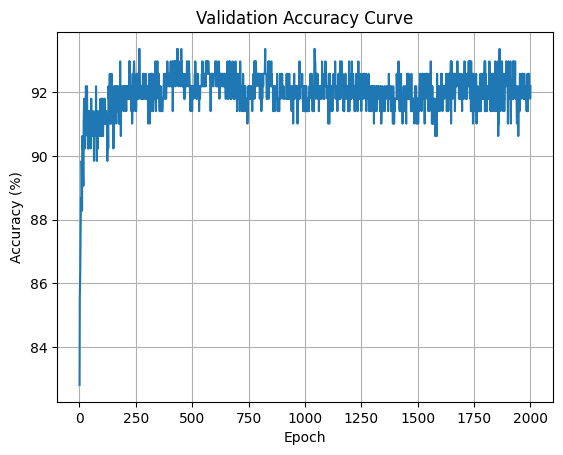

In [ ]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

df = pd.read_csv("train.csv", encoding="latin1", sep=",", engine='python')
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)
binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]

target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 2000
best_acc = 0
acc_list = []

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        acc = (val_preds.round() == y_test).float().mean().item()
        acc_list.append(acc)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Accuracy: {acc * 100:.2f}%")

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    final_preds = model(X_test)
    final_acc = (final_preds.round() == y_test).float().mean().item()
    map_score = average_precision_score(y_test.cpu().numpy(), final_preds.cpu().numpy())
    print(f"\n Final Test Accuracy: {final_acc * 100:.2f}%")
    print(f" Mean Average Precision (mAP): {map_score:.4f}")

plt.plot(range(1, epochs + 1), [a * 100 for a in acc_list])
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


Using device: cuda
Epoch 10/5000 | Accuracy: 89.84%
Epoch 20/5000 | Accuracy: 91.41%
Epoch 30/5000 | Accuracy: 91.80%
Epoch 40/5000 | Accuracy: 90.23%
Epoch 50/5000 | Accuracy: 90.23%
Epoch 60/5000 | Accuracy: 91.41%
Epoch 70/5000 | Accuracy: 91.41%
Epoch 80/5000 | Accuracy: 90.23%
Epoch 90/5000 | Accuracy: 91.02%
Epoch 100/5000 | Accuracy: 91.80%
Epoch 110/5000 | Accuracy: 91.41%
Epoch 120/5000 | Accuracy: 91.02%
Epoch 130/5000 | Accuracy: 91.80%
Epoch 140/5000 | Accuracy: 92.19%
Epoch 150/5000 | Accuracy: 91.41%
Epoch 160/5000 | Accuracy: 91.80%
Epoch 170/5000 | Accuracy: 92.19%
Epoch 180/5000 | Accuracy: 91.41%
Epoch 190/5000 | Accuracy: 92.19%
Epoch 200/5000 | Accuracy: 92.19%
Epoch 210/5000 | Accuracy: 91.80%
Epoch 220/5000 | Accuracy: 92.19%
Epoch 230/5000 | Accuracy: 91.41%
Epoch 240/5000 | Accuracy: 91.41%
Epoch 250/5000 | Accuracy: 91.41%
Epoch 260/5000 | Accuracy: 91.80%
Epoch 270/5000 | Accuracy: 92.19%
Epoch 280/5000 | Accuracy: 91.80%
Epoch 290/5000 | Accuracy: 92.19%
Epoc

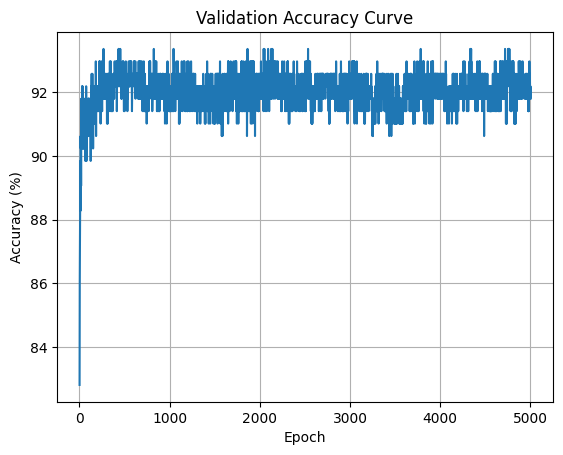

In [ ]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


df = pd.read_csv("train.csv", encoding="latin1", sep=",", engine='python')


df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]


for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)


le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)
binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]

target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)


X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)


train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)


epochs = 5000
best_acc = 0
acc_list = []

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        acc = (val_preds.round() == y_test).float().mean().item()
        acc_list.append(acc)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Accuracy: {acc * 100:.2f}%")

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    final_preds = model(X_test)
    final_acc = (final_preds.round() == y_test).float().mean().item()
    map_score = average_precision_score(y_test.cpu().numpy(), final_preds.cpu().numpy())
    print(f"\n🎯 Final Test Accuracy: {final_acc * 100:.2f}%")
    print(f"📈 Mean Average Precision (mAP): {map_score:.4f}")


plt.plot(range(1, epochs + 1), [a * 100 for a in acc_list])
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


In [60]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
import warnings

warnings.filterwarnings("ignore")

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load and preprocess dataset
df = pd.read_csv("train.csv")
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

# Drop irrelevant columns
for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Encode categorical variables
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Feature engineering
score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)

binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)

if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]

df["interaction_term"] = df["binary_sum"] * df["total_score"]

# Define target
target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# Polynomial features + Scaling + SMOTE
poly = PolynomialFeatures(2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_res, y_res = SMOTE(random_state=42).fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Pytorch Neural Network
class DNN(nn.Module):
    def __init__(self, input_dim):
        super(DNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Train Neural Net
def train_nn(X_train, y_train, X_test, input_dim):
    model = DNN(input_dim).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    X_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for epoch in range(100):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy().flatten()
    return preds

# Train base models
cb_model = CatBoostClassifier(verbose=0, iterations=500, learning_rate=0.03, depth=10)
lgbm_model = LGBMClassifier(n_estimators=500, learning_rate=0.05)

cb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)
cb_preds = cb_model.predict_proba(X_test)[:, 1]
lgbm_preds = lgbm_model.predict_proba(X_test)[:, 1]
nn_preds = train_nn(X_train, y_train, X_test, X_train.shape[1])

# Stacking meta-model
stacked_input = np.vstack((cb_preds, lgbm_preds, nn_preds)).T
meta_model = LogisticRegression()
meta_model.fit(stacked_input, y_test)
final_preds = meta_model.predict(stacked_input)

# Final accuracy
acc = accuracy_score(y_test, final_preds)
print("📊 Stacked Ensemble Accuracy:", round(acc * 100, 2), "%")


[LightGBM] [Info] Number of positive: 508, number of negative: 514
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21170
[LightGBM] [Info] Number of data points in the train set: 1022, number of used features: 300
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497065 -> initscore=-0.011742
[LightGBM] [Info] Start training from score -0.011742
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [ ]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

df = pd.read_csv("train.csv", encoding="latin1", sep=",", engine='python')


df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]


for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Label encoding
le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Feature engineering
score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)
binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]


target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)


X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)


train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)


epochs = 2000
best_acc = 0
acc_list = []

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        acc = (val_preds.round() == y_test).float().mean().item()
        acc_list.append(acc)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Accuracy: {acc * 100:.2f}%")


model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    final_preds = model(X_test)
    final_acc = (final_preds.round() == y_test).float().mean().item()
    map_score = average_precision_score(y_test.cpu().numpy(), final_preds.cpu().numpy())
    print(f"\n🎯 Final Test Accuracy: {final_acc * 100:.2f}%")
    print(f"📈 Mean Average Precision (mAP): {map_score:.4f}")


plt.plot(range(1, epochs + 1), [a * 100 for a in acc_list])
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


Using device: cuda
Epoch 10/9000 | Accuracy: 89.84%
Epoch 20/9000 | Accuracy: 91.41%
Epoch 30/9000 | Accuracy: 91.80%
Epoch 40/9000 | Accuracy: 90.23%
Epoch 50/9000 | Accuracy: 90.23%
Epoch 60/9000 | Accuracy: 91.41%
Epoch 70/9000 | Accuracy: 91.41%
Epoch 80/9000 | Accuracy: 90.23%
Epoch 90/9000 | Accuracy: 91.02%
Epoch 100/9000 | Accuracy: 91.80%
Epoch 110/9000 | Accuracy: 91.41%
Epoch 120/9000 | Accuracy: 91.02%
Epoch 130/9000 | Accuracy: 91.80%
Epoch 140/9000 | Accuracy: 92.19%
Epoch 150/9000 | Accuracy: 91.41%
Epoch 160/9000 | Accuracy: 91.80%
Epoch 170/9000 | Accuracy: 92.19%
Epoch 180/9000 | Accuracy: 91.41%
Epoch 190/9000 | Accuracy: 92.19%
Epoch 200/9000 | Accuracy: 92.19%
Epoch 210/9000 | Accuracy: 91.80%
Epoch 220/9000 | Accuracy: 92.19%
Epoch 230/9000 | Accuracy: 91.41%
Epoch 240/9000 | Accuracy: 91.41%
Epoch 250/9000 | Accuracy: 91.41%
Epoch 260/9000 | Accuracy: 91.80%
Epoch 270/9000 | Accuracy: 92.19%
Epoch 280/9000 | Accuracy: 91.80%
Epoch 290/9000 | Accuracy: 92.19%
Epoc

KeyboardInterrupt: 

Using device: cuda
Epoch 10/2000 | Accuracy: 89.84%
Epoch 20/2000 | Accuracy: 91.41%
Epoch 30/2000 | Accuracy: 91.80%
Epoch 40/2000 | Accuracy: 90.23%
Epoch 50/2000 | Accuracy: 90.23%
Epoch 60/2000 | Accuracy: 91.41%
Epoch 70/2000 | Accuracy: 91.41%
Epoch 80/2000 | Accuracy: 90.23%
Epoch 90/2000 | Accuracy: 91.02%
Epoch 100/2000 | Accuracy: 91.80%
Epoch 110/2000 | Accuracy: 91.41%
Epoch 120/2000 | Accuracy: 91.02%
Epoch 130/2000 | Accuracy: 91.80%
Epoch 140/2000 | Accuracy: 92.19%
Epoch 150/2000 | Accuracy: 91.41%
Epoch 160/2000 | Accuracy: 91.80%
Epoch 170/2000 | Accuracy: 92.19%
Epoch 180/2000 | Accuracy: 91.41%
Epoch 190/2000 | Accuracy: 92.19%
Epoch 200/2000 | Accuracy: 92.19%
Epoch 210/2000 | Accuracy: 91.80%
Epoch 220/2000 | Accuracy: 92.19%
Epoch 230/2000 | Accuracy: 91.41%
Epoch 240/2000 | Accuracy: 91.41%
Epoch 250/2000 | Accuracy: 91.41%
Epoch 260/2000 | Accuracy: 91.80%
Epoch 270/2000 | Accuracy: 92.19%
Epoch 280/2000 | Accuracy: 91.80%
Epoch 290/2000 | Accuracy: 92.19%
Epoc

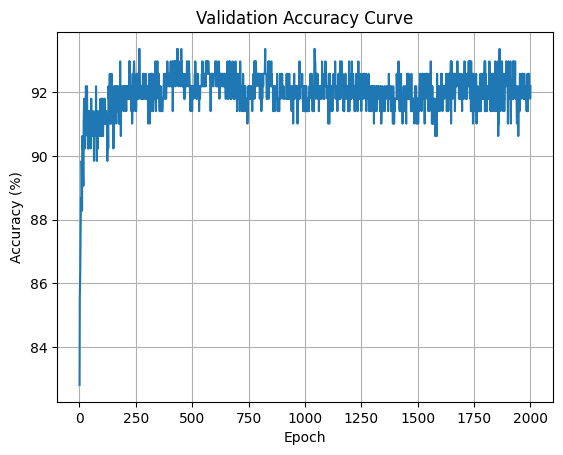

In [ ]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

df = pd.read_csv("train.csv", encoding="latin1", sep=",", engine='python')


df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)
binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]

target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 2000
best_acc = 0
acc_list = []

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        acc = (val_preds.round() == y_test).float().mean().item()
        acc_list.append(acc)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Accuracy: {acc * 100:.2f}%")

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    final_preds = model(X_test)
    final_acc = (final_preds.round() == y_test).float().mean().item()
    map_score = average_precision_score(y_test.cpu().numpy(), final_preds.cpu().numpy())
    print(f"\n Mean Average Precision (mAP): {final_acc * 100:.2f}%")
   
plt.plot(range(1, epochs + 1), [a * 100 for a in acc_list])
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


Using device: cuda
Epoch 10/500 | Accuracy: 82.50%
⏹️ Early stopping triggered at epoch 13

✅ Final Test Accuracy: 85.00%
📈 Mean Average Precision (mAP): 75.68%


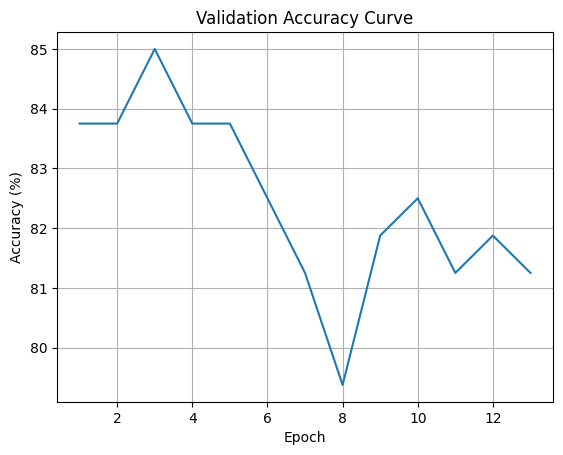

In [ ]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


df = pd.read_csv("train.csv", encoding="latin1")

df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)


le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le


score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)
binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]

target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 500
patience = 10
best_acc = 0
acc_list = []
trigger_times = 0

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        acc = (val_preds.round() == y_test).float().mean().item()
        acc_list.append(acc)

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"⏹️ Early stopping triggered at epoch {epoch + 1}")
                break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Accuracy: {acc * 100:.2f}%")


model.load_state_dict(torch.load("best_model.pt"))
model.eval()


with torch.no_grad():
    final_preds = model(X_test)
    final_acc = (final_preds.round() == y_test).float().mean().item()
    map_score = average_precision_score(y_test.cpu().numpy(), final_preds.cpu().numpy())
    print(f"\n Final Test Accuracy: {final_acc * 100:.2f}%")
    print(f" Mean Average Precision (mAP): {map_score * 100:.2f}%")


plt.plot(range(1, len(acc_list)+1), [a * 100 for a in acc_list])
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


Using device: cuda
Epoch 10/500 | Accuracy: 81.25%

⏹️ Early stopping triggered at epoch 12
[LightGBM] [Info] Number of positive: 515, number of negative: 515
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1253
[LightGBM] [Info] Number of data points in the train set: 1030, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

✅ Final NN Accuracy: 84.38%
✅ Final Ensemble Accuracy: 83.12%
📈 Mean Average Precision (mAP): 69.83%


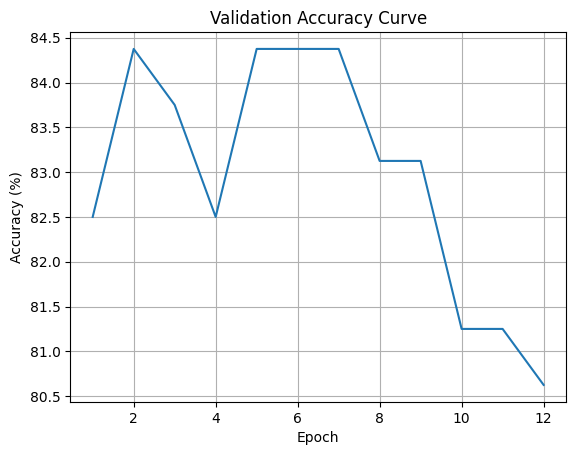

In [ ]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load and preprocess data
df = pd.read_csv("train.csv", encoding="latin1")
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Encode categorical columns
le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Feature engineering
score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)
binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]

target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# Standardize and split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Apply SMOTE on training data
X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

# Convert to tensors for PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Define neural network
class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# Early stopping params
epochs = 500
patience = 10
best_acc = 0
trigger_times = 0
acc_list = []

# Train loop with early stopping
for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_test_tensor)
        acc = (val_preds.round() == y_test_tensor).float().mean().item()
        acc_list.append(acc)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"\n⏹️ Early stopping triggered at epoch {epoch + 1}")
                break
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs} | Accuracy: {acc * 100:.2f}%")

# Load best model
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
with torch.no_grad():
    nn_preds = model(X_test_tensor).cpu().numpy().flatten()
    final_nn_acc = (nn_preds.round() == y_test.values).mean()

# Train LightGBM
lgb = LGBMClassifier(n_estimators=500, learning_rate=0.03)
lgb.fit(X_train, y_train)
lgb_preds = lgb.predict_proba(X_test)[:, 1]

# Ensemble average
combined_preds = (nn_preds + lgb_preds) / 2
ensemble_final = (combined_preds >= 0.5).astype(int)
ensemble_acc = accuracy_score(y_test, ensemble_final)
map_score = average_precision_score(y_test, combined_preds)

print(f"\nFinal NN Accuracy: {final_nn_acc * 100:.2f}%")
print(f" Final Ensemble Accuracy: {ensemble_acc * 100:.2f}%")
print(f" Mean Average Precision (mAP): {map_score * 100:.2f}%")

# Plot accuracy curve
plt.plot(range(1, len(acc_list)+1), [a * 100 for a in acc_list])
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()
